In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D 
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.preprocessing import image 
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

In [3]:
train_path =r"C:\Users\hp\Downloads\training_set\training_set"
test_path =r"C:\Users\hp\Downloads\test_set\test_set"

In [4]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'

)

print(train_data.class_indices)

Found 8005 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [5]:
test_data = test_gen.flow_from_directory(
    test_path, 
    target_size=(128, 128), 
    batch_size=32,
    class_mode="binary"
)
print(test_data.class_indices)

Found 2023 images belonging to 2 classes.
{'cats': 0, 'dogs': 1}


In [6]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D (pool_size=(2,2)))
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D (pool_size=(2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D (pool_size=(2,2)))

model.add(Flatten())

model.add(Dense (128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense (1, activation='sigmoid'))

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
es = EarlyStopping(
    monitor='val_loss',   
    patience=3,          
    restore_best_weights=True  
)


In [10]:

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10        
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 112s 439ms/step - accuracy: 0.5609 - loss: 0.6839 - val_accuracy: 0.5487 - val_loss: 0.6971
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 118s 470ms/step - accuracy: 0.6450 - loss: 0.6376 - val_accuracy: 0.7029 - val_loss: 0.5880
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 130s 518ms/step - accuracy: 0.6838 - loss: 0.5973 - val_accuracy: 0.7217 - val_loss: 0.5642
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 118s 470ms/step - accuracy: 0.7082 - loss: 0.5631 - val_accuracy: 0.7390 - val_loss: 0.5246
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 115s 459ms/step - accuracy: 0.7242 - loss: 0.5506 - val_accuracy: 0.7603 - val_loss: 0.4976
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 118s 469ms/step - accuracy: 0.7615 - loss: 0.4978 - val_accuracy: 0.7711 - val_loss: 0.4769
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 123s 491ms/step - accuracy: 0.7715 - loss: 0.4769 - val_accuracy: 0.7865 - val_loss: 0.4587
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 131s 523ms/step - accuracy: 0.7913 -

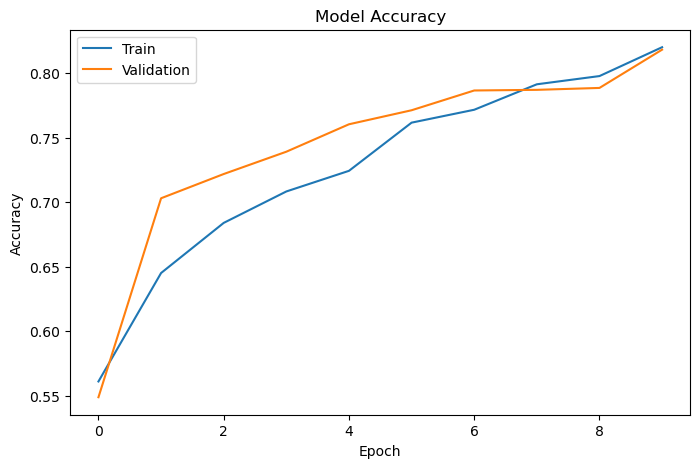

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

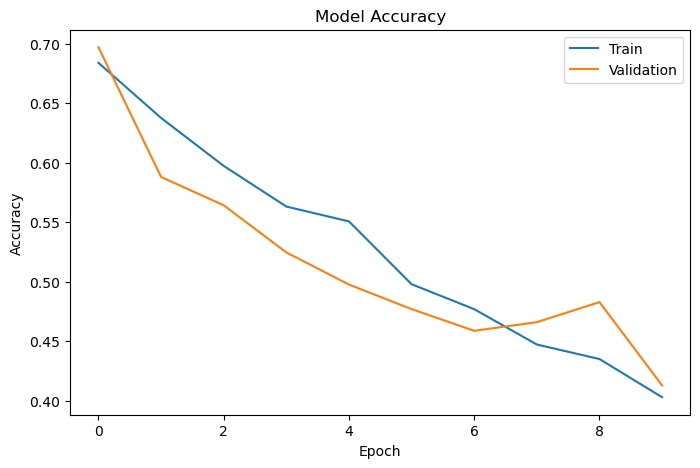

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

In [13]:
loss, acc = model.evaluate(test_data)

print("Accuracy",acc)
print("loss",loss)

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.8181 - loss: 0.4128 
Accuracy 0.8180919289588928
loss 0.4127765893936157


In [14]:
model.save("cat_dog_cnn.h5")
print("model saved successfully!")

model saved successfully!


In [15]:
model = load_model("cat_dog_cnn.h5")

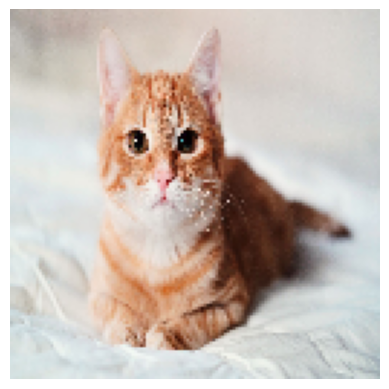

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
prediction score : 0.299577
cat


In [20]:
img_path =r"C:\Users\hp\Downloads\GingerTabbyShorthair-e3b45511a76a4b25a6fb421e60f04025.jpg"
img = image.load_img(
    img_path,
    target_size= (128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr, axis=0)

pred = model.predict(img_arr)

print("prediction score :", pred[0][0])

if pred[0][0] >0.5:
    print("dog")
else:
    print("cat")

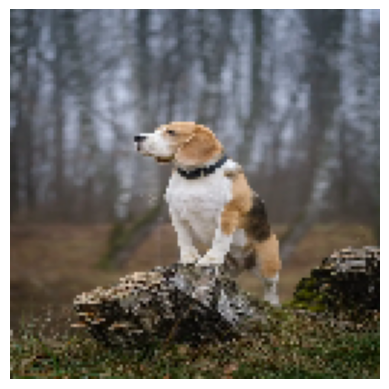

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
prediction score: 0.91914284
dog


In [21]:

model = load_model("cat_dog_cnn.h5")

img_path =r"C:\Users\hp\Downloads\funny-dog-breed-beagle-walk-autumn-park-thick-fog-portrait-landscape-background-164231276.webp"

img = image.load_img(img_path,target_size=(128,128))

plt.imshow(img)
plt.axis("off")
plt.show()

img_arr = image.img_to_array(img)
img_arr = img_arr / 255.0
img_arr = np.expand_dims(img_arr,axis=0)

pred = model.predict(img_arr)

print("prediction score:",pred[0][0])

if pred[0][0] >0.5:
    print("dog")
else:
    print("cat")